# Experimentos finais — BERTimbau e emoções de Ekman (GoEmotions PT-BR)

Comparação multi-label em sete rótulos (`6 grupos de Ekman + neutral`):

1. **BERTimbau + CB Loss**: baseline já treinado, reutilizado de `data/out/bert_ekman` e `data/checkpoints/bert_ekman`;
2. **BERTimbau + CB Loss + descrições**;
3. **BERTimbau + Distribution-Balanced Loss**;
4. **BERTimbau + Distribution-Balanced Loss + descrições**.

O desenho separa o efeito das descrições, da nova perda e da combinação. A versão com descrições usa a visão instância–rótulo inspirada no TACO, sem CCL e LDL.

O valor de `0.64` do GoEmotions original não é diretamente comparável: corresponde ao corpus em inglês e ao agrupamento Ekman em seis categorias. Aqui são usados textos traduzidos, sete saídas incluindo `neutral`, folds próprios e calibração de limiar.

Referências:

- [GoEmotions](https://arxiv.org/abs/2005.00547)
- [TACO](https://aclanthology.org/2025.acl-long.247/)
- [Distribution-Balanced Loss](https://arxiv.org/abs/2007.09654)
- [Distribution-Balanced Loss em classificação multi-label de texto](https://aclanthology.org/2021.emnlp-main.643/)


## Instalação (se necessário)

In [1]:
# !pip install "transformers>=4.48" torch torchmetrics pandas numpy scikit-learn pyarrow sentencepiece protobuf scipy matplotlib

## Ambiente (Colab/Drive opcional)

In [2]:
USE_COLAB = False
USE_DRIVE = False

if USE_COLAB:
    from google.colab import drive
    if USE_DRIVE:
        drive.mount('/content/drive')


## Imports e configurações globais

In [3]:
import warnings
warnings.filterwarnings("ignore")

import io, re, gzip, lzma, json, time, math, zipfile
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Optimizer

from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, hamming_loss, average_precision_score,
)
from scipy.stats import wilcoxon

import matplotlib.pyplot as plt

RANDOM_STATE = 42

if USE_COLAB and USE_DRIVE:
    ROOT = Path("/content/drive/MyDrive/Fuzzy_BERT")
else:
    ROOT = Path("..")

DATA_DIR = ROOT / "data/treated"
OUT_BASE = ROOT / "data/out"
CKPT_BASE = ROOT / "data/checkpoints"

N_OUTER_FOLDS = 5
TEXT_COL = "CLEAN_TEXT"
MAX_LEN = 128
BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 1
WARMUP_RATIO = 0.1
LEARNING_RATE = 2e-5
VAL_FRACTION = 0.10
NUM_EPOCHS = 4

THRESH_GRID = np.linspace(0.05, 0.95, 19)
FIXED_THRESHOLD = 0.5

COMPRESSION = "xz"
SAVE_BEST_FP16 = True
PRUNE_RESUME_CKPT = True
REBUILD_BASELINE_OOF_FROM_CHECKPOINTS = True

MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASELINE_EXPECTED_MEAN = 0.5814
BASELINE_EXPECTED_STD = 0.0044

EMOTION_COLS_28 = [
    'admiration','amusement','anger','annoyance','approval','caring','confusion','curiosity',
    'desire','disappointment','disapproval','disgust','embarrassment','excitement','fear',
    'gratitude','grief','joy','love','nervousness','optimism','pride','realization','relief',
    'remorse','sadness','surprise','neutral'
]

EKMAN7 = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]
N_LABELS = len(EKMAN7)

EKMAN_FROM_FINE = {
    "anger": ["anger", "annoyance", "disapproval"],
    "disgust": ["disgust"],
    "fear": ["fear", "nervousness"],
    "joy": ["admiration", "amusement", "approval", "caring", "desire", "excitement", "gratitude", "joy", "love", "optimism", "pride", "relief"],
    "sadness": ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
    "surprise": ["surprise", "realization", "confusion", "curiosity"],
}

SENT_FROM_EKMAN = {
    "positive": ["joy"],
    "negative": ["anger", "disgust", "fear", "sadness"],
    "ambiguous": ["surprise"],
    "neutral": ["neutral"],
}
SENT4 = list(SENT_FROM_EKMAN)

_fine_no_neutral = [column for column in EMOTION_COLS_28 if column != "neutral"]
assert sorted(sum(EKMAN_FROM_FINE.values(), [])) == sorted(_fine_no_neutral)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(f"Device : {DEVICE}")
print(f"Modelo : {MODEL_NAME}")
print(f"Alvo   : {N_LABELS} rótulos -> {EKMAN7}")


Device : cuda
Modelo : neuralmind/bert-base-portuguese-cased
Alvo   : 7 rótulos -> ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']


## Construção dos rótulos de Ekman (7) a partir das 28 colunas finas

In [4]:
def build_ekman_df(df):
    out = pd.DataFrame(index=df.index)
    for group, members in EKMAN_FROM_FINE.items():
        out[group] = (df[members].sum(axis=1) > 0).astype(int)
    out["neutral"] = df["neutral"].astype(int)
    out = out[EKMAN7]
    out[TEXT_COL] = df[TEXT_COL].values
    return out.reset_index(drop=True)

def load_fold(fold_id):
    return pd.read_parquet(DATA_DIR / f"fold_{fold_id}" / "data.parquet")

folds_ek = {}
for k in range(1, N_OUTER_FOLDS + 1):
    raw = load_fold(k)
    missing = [c for c in EMOTION_COLS_28 if c not in raw.columns]
    assert not missing, f"Fold {k} sem colunas finas: {missing}"
    folds_ek[k] = build_ekman_df(raw)

Y_folds = {k: folds_ek[k][EKMAN7].values.astype(int) for k in folds_ek}
base_rates = pd.Series(np.vstack(list(Y_folds.values())).mean(axis=0), index=EKMAN7)
cardinality = np.vstack(list(Y_folds.values())).sum(axis=1)

print("Rótulos de Ekman construídos.\n")
print("Frequência por rótulo:")
for label in EKMAN7:
    print(f"  {label:9s}: {base_rates[label]:.4f}")
print(f"\nMédia de rótulos por texto: {cardinality.mean():.3f} | "
      f"multi-label: {100 * (cardinality > 1).mean():.1f}% | "
      f"sem rótulo: {100 * (cardinality == 0).mean():.1f}%")


Rótulos de Ekman construídos.

Frequência por rótulo:
  anger    : 0.1295
  disgust  : 0.0187
  fear     : 0.0171
  joy      : 0.4007
  sadness  : 0.0743
  surprise : 0.1229
  neutral  : 0.3273

Média de rótulos por texto: 1.090 | multi-label: 8.8% | sem rótulo: 0.0%


## Descrições dos rótulos de Ekman

In [5]:
LABEL_NAMES_PT = {
    "anger": "raiva",
    "disgust": "nojo",
    "fear": "medo",
    "joy": "alegria",
    "sadness": "tristeza",
    "surprise": "surpresa",
    "neutral": "neutro",
}

LABEL_DESCRIPTIONS = {
    "anger": "Sentimento intenso de irritação, indignação ou antagonismo.",
    "disgust": "Repulsa ou forte desaprovação provocada por algo desagradável ou ofensivo.",
    "fear": "Estar com medo ou preocupado diante de uma ameaça ou possibilidade negativa.",
    "joy": "Sentimento de prazer, felicidade e bem-estar.",
    "sadness": "Dor emocional ou sentimento de pesar.",
    "surprise": "Sentimento de espanto ou admiração diante de algo inesperado.",
    "neutral": "Ausência de emoção marcante; enunciado informativo, factual ou indiferente, sem carga afetiva positiva ou negativa clara.",
}

assert set(LABEL_NAMES_PT) == set(EKMAN7)
assert set(LABEL_DESCRIPTIONS) == set(EKMAN7)

display(pd.DataFrame({
    "rótulo": EKMAN7,
    "nome_pt": [LABEL_NAMES_PT[label] for label in EKMAN7],
    "descrição": [LABEL_DESCRIPTIONS[label] for label in EKMAN7],
}))


,rótulo,nome_pt,descrição
0,anger,raiva,"Sentimento intenso de irritação, indignação ou..."
1,disgust,nojo,Repulsa ou forte desaprovação provocada por al...
2,fear,medo,Estar com medo ou preocupado diante de uma ame...
3,joy,alegria,"Sentimento de prazer, felicidade e bem-estar."
4,sadness,tristeza,Dor emocional ou sentimento de pesar.
5,surprise,surpresa,Sentimento de espanto ou admiração diante de a...
6,neutral,neutro,Ausência de emoção marcante; enunciado informa...


## Experimentos finais

In [6]:
EXPERIMENTS = {
    "bert_cb": {
        "display": "BERTimbau + CB Loss",
        "kind": "plain",
        "loss": "cb",
        "reuse_baseline": True,
        "out_dir": OUT_BASE / "bert_ekman",
        "ckpt_dir": CKPT_BASE / "bert_ekman",
        "oof_name": "P_ekman_fold{fold}.npy",
    },
    "bert_cb_desc": {
        "display": "BERTimbau + CB Loss + descrições",
        "kind": "description",
        "loss": "cb",
        "reuse_baseline": False,
    },
    "bert_db": {
        "display": "BERTimbau + DB Loss",
        "kind": "plain",
        "loss": "db",
        "reuse_baseline": False,
    },
    "bert_db_desc": {
        "display": "BERTimbau + DB Loss + descrições",
        "kind": "description",
        "loss": "db",
        "reuse_baseline": False,
    },
}

for key, cfg in EXPERIMENTS.items():
    cfg.update({"key": key, "model_name": MODEL_NAME, "num_epochs": NUM_EPOCHS})
    if not cfg["reuse_baseline"]:
        cfg["out_dir"] = OUT_BASE / f"final_bert_ekman_{key}"
        cfg["ckpt_dir"] = CKPT_BASE / f"final_bert_ekman_{key}"
        cfg["oof_name"] = f"P_{key}_fold{{fold}}.npy"
    (cfg["out_dir"] / "cache").mkdir(parents=True, exist_ok=True)
    cfg["ckpt_dir"].mkdir(parents=True, exist_ok=True)

for cfg in EXPERIMENTS.values():
    source = "cache/checkpoint existente" if cfg["reuse_baseline"] else "novo treinamento"
    print(f"{cfg['display']:42s} | {source}")


BERTimbau + CB Loss                        | cache/checkpoint existente
BERTimbau + CB Loss + descrições           | novo treinamento
BERTimbau + DB Loss                        | novo treinamento
BERTimbau + DB Loss + descrições           | novo treinamento


## Dataset e DataLoader (7 rótulos de Ekman)

In [7]:
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, label_cols=EKMAN7, max_len=MAX_LEN):
        self.texts = df[TEXT_COL].fillna("").astype(str).tolist()
        self.labels = df[label_cols].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(self.texts[idx], max_length=self.max_len, truncation=True)
        encoded["labels"] = self.labels[idx].tolist()
        return encoded

def make_loaders(df_train, df_eval, tokenizer, shuffle_train=True):
    collator = DataCollatorWithPadding(tokenizer, padding="longest", return_tensors="pt")
    loader_train = DataLoader(
        EmotionDataset(df_train, tokenizer), batch_size=BATCH_SIZE,
        shuffle=shuffle_train, num_workers=0, pin_memory=DEVICE.type == "cuda",
        collate_fn=collator,
    )
    loader_eval = DataLoader(
        EmotionDataset(df_eval, tokenizer), batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0, pin_memory=DEVICE.type == "cuda",
        collate_fn=collator,
    )
    return loader_train, loader_eval

def split_train_val(df_trainfull, val_fraction=VAL_FRACTION, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    permutation = rng.permutation(len(df_trainfull))
    n_val = max(1, int(round(len(df_trainfull) * val_fraction)))
    return (
        df_trainfull.iloc[permutation[n_val:]].reset_index(drop=True),
        df_trainfull.iloc[permutation[:n_val]].reset_index(drop=True),
    )

print("Dataset e loaders prontos.")


Dataset e loaders prontos.


## Modelos — cabeça linear e codificação com descrições

In [8]:
def prepare_encoder(model_name, tokenizer=None):
    encoder = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32)
    if tokenizer is not None:
        encoder.resize_token_embeddings(len(tokenizer))
    return encoder

class TransformerForEmotions(nn.Module):
    def __init__(self, model_name, n_labels=N_LABELS, dropout=0.1):
        super().__init__()
        self.bert = prepare_encoder(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_labels)

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(output.last_hidden_state[:, 0, :]))

class ProjectionHead(nn.Module):
    def __init__(self, hidden_size, projection_size=128):
        super().__init__()
        self.layers = nn.Sequential(nn.Linear(hidden_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, projection_size))

    def forward(self, values):
        return self.layers(values)

def build_label_tensors(tokenizer, max_len=64):
    texts = [f"{LABEL_NAMES_PT[label]} [EMO] {LABEL_DESCRIPTIONS[label]}" for label in EKMAN7]
    encoded = tokenizer(texts, padding="max_length", truncation=True, max_length=max_len, return_tensors="pt")
    return encoded["input_ids"], encoded["attention_mask"]

class DescriptionAwareForEmotions(nn.Module):
    def __init__(self, model_name, tokenizer, projection_size=128, dropout=0.1):
        super().__init__()
        self.bert = prepare_encoder(model_name, tokenizer)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.instance_head = ProjectionHead(hidden_size, projection_size)
        self.label_head = ProjectionHead(hidden_size, projection_size)
        self.label_bias = nn.Parameter(torch.zeros(N_LABELS))
        label_ids, label_mask = build_label_tensors(tokenizer)
        self.register_buffer("label_input_ids", label_ids, persistent=False)
        self.register_buffer("label_attention_mask", label_mask, persistent=False)

    def encode_labels(self):
        output = self.bert(input_ids=self.label_input_ids, attention_mask=self.label_attention_mask)
        return self.label_head(output.last_hidden_state[:, 0, :])

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        instance_embeddings = self.instance_head(self.dropout(output.last_hidden_state[:, 0, :]))
        label_embeddings = self.encode_labels()
        return instance_embeddings @ label_embeddings.T / math.sqrt(instance_embeddings.shape[-1]) + self.label_bias

def build_model(cfg, tokenizer):
    if cfg["kind"] == "description":
        return DescriptionAwareForEmotions(cfg["model_name"], tokenizer).to(DEVICE)
    return TransformerForEmotions(cfg["model_name"]).to(DEVICE)

print("Modelos definidos.")


Modelos definidos.


## Perdas — Class-Balanced Loss e Distribution-Balanced Loss

In [9]:
class CrossBalancedLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.9999):
        super().__init__()
        effective_num = 1.0 - np.power(beta, samples_per_class)
        weights = (1.0 - beta) / np.where(effective_num == 0, 1e-8, effective_num)
        weights = weights / weights.sum() * len(samples_per_class)
        self.register_buffer("weights", torch.tensor(weights, dtype=torch.float32))

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        return (bce * self.weights.unsqueeze(0)).mean()

class DistributionBalancedLoss(nn.Module):
    def __init__(self, class_freq, train_num, map_alpha=0.1, map_beta=10.0, map_gamma=0.405, focal_alpha=0.5, focal_gamma=2.0, init_bias=0.05, neg_scale=2.0):
        super().__init__()
        class_freq = torch.tensor(class_freq, dtype=torch.float32)
        self.register_buffer("freq_inv", 1.0 / class_freq.clamp_min(1.0))
        self.register_buffer("init_bias", -torch.log(train_num / class_freq.clamp_max(train_num - 1) - 1) * init_bias)
        self.map_alpha = map_alpha
        self.map_beta = map_beta
        self.map_gamma = map_gamma
        self.focal_alpha = focal_alpha
        self.focal_gamma = focal_gamma
        self.neg_scale = neg_scale

    def forward(self, logits, targets):
        repeat_rate = (targets * self.freq_inv.unsqueeze(0)).sum(dim=1, keepdim=True).clamp_min(1e-8)
        pos_weight = self.freq_inv.unsqueeze(0) / repeat_rate
        weight = torch.sigmoid(self.map_beta * (pos_weight - self.map_gamma)) + self.map_alpha

        logits = logits + self.init_bias.unsqueeze(0)
        logits = logits * (targets + (1.0 - targets) * self.neg_scale)
        weight = weight * (targets + (1.0 - targets) / self.neg_scale)

        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probability = torch.exp(-bce)
        alpha = targets * self.focal_alpha + (1.0 - targets) * (1.0 - self.focal_alpha)
        return (alpha * (1.0 - probability).pow(self.focal_gamma) * bce * weight).mean()

def compute_samples_per_class(df, label_cols=EKMAN7):
    counts = np.array([int(df[column].sum()) for column in label_cols], dtype=np.float64)
    return np.maximum(counts, 1)

def build_criterion(cfg, df_train):
    class_freq = compute_samples_per_class(df_train)
    if cfg["loss"] == "cb":
        return CrossBalancedLoss(class_freq, beta=0.9999).to(DEVICE)
    if cfg["loss"] == "db":
        return DistributionBalancedLoss(class_freq, len(df_train)).to(DEVICE)
    raise ValueError(f"Perda desconhecida: {cfg['loss']}")

print("Perdas definidas.")


Perdas definidas.


## Otimizador e scheduler (mesma família do baseline)

In [10]:
class AdamWeightDecayOptimizer(Optimizer):
    def __init__(self, params, lr=2e-5, weight_decay_rate=0.01,
                 beta_1=0.9, beta_2=0.999, epsilon=1e-6, exclude_from_weight_decay=None):
        if exclude_from_weight_decay is None:
            exclude_from_weight_decay = ["LayerNorm", "layer_norm", "bias"]
        defaults = dict(
            lr=lr, weight_decay_rate=weight_decay_rate, beta_1=beta_1,
            beta_2=beta_2, epsilon=epsilon,
            exclude_from_weight_decay=exclude_from_weight_decay,
        )
        super().__init__(params, defaults)

    def _use_weight_decay(self, name, exclusions):
        return not any(re.search(pattern, name) for pattern in exclusions)

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure is not None else None
        for group in self.param_groups:
            beta_1, beta_2, epsilon = group["beta_1"], group["beta_2"], group["epsilon"]
            weight_decay, learning_rate = group["weight_decay_rate"], group["lr"]
            exclusions = group["exclude_from_weight_decay"]
            names = group.get("_param_names", {})
            for parameter in group["params"]:
                if parameter.grad is None:
                    continue
                gradient = parameter.grad.data
                state = self.state[parameter]
                if len(state) == 0:
                    state["m"] = torch.zeros_like(parameter.data)
                    state["v"] = torch.zeros_like(parameter.data)
                    state["step"] = 0
                m, v = state["m"], state["v"]
                state["step"] += 1
                next_m = beta_1 * m + (1.0 - beta_1) * gradient
                next_v = beta_2 * v + (1.0 - beta_2) * gradient.pow(2)
                update = next_m / (next_v.sqrt() + epsilon)
                if weight_decay > 0 and self._use_weight_decay(names.get(id(parameter), ""), exclusions):
                    update += weight_decay * parameter.data
                parameter.data.add_(update, alpha=-learning_rate)
                state["m"].copy_(next_m)
                state["v"].copy_(next_v)
        return loss

def build_optimizer(model, lr=LEARNING_RATE):
    decay, no_decay, names = [], [], {}
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        names[id(parameter)] = name
        target = no_decay if any(pattern in name for pattern in ["LayerNorm", "layer_norm", "bias"]) else decay
        target.append(parameter)
    groups = [
        {"params": decay, "weight_decay_rate": 0.01},
        {"params": no_decay, "weight_decay_rate": 0.0},
    ]
    optimizer = AdamWeightDecayOptimizer(groups, lr=lr)
    for group in optimizer.param_groups:
        group["_param_names"] = names
    return optimizer

def build_scheduler(optimizer, num_steps, warmup_ratio=WARMUP_RATIO):
    from torch.optim.lr_scheduler import LambdaLR
    warmup_steps = int(num_steps * warmup_ratio)

    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        progress = float(step - warmup_steps) / float(max(1, num_steps - warmup_steps))
        return max(0.0, 1.0 - progress)

    return LambdaLR(optimizer, lr_lambda)

print("Otimizador e scheduler prontos.")


Otimizador e scheduler prontos.


## Checkpoints compactados + treino/avaliação + métricas

In [11]:
def _compress(raw):
    if COMPRESSION == "gzip":
        return gzip.compress(raw, 6)
    if COMPRESSION == "xz":
        return lzma.compress(raw, preset=6)
    if COMPRESSION == "zip":
        buffer = io.BytesIO()
        with zipfile.ZipFile(buffer, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as archive:
            archive.writestr("ckpt.pt", raw)
        return buffer.getvalue()
    raise ValueError(COMPRESSION)

def _decompress(data):
    if data[:2] == b"\x1f\x8b":
        return gzip.decompress(data)
    if data[:6] == b"\xfd7zXZ\x00":
        return lzma.decompress(data)
    if data[:2] == b"PK":
        with zipfile.ZipFile(io.BytesIO(data)) as archive:
            return archive.read(archive.namelist()[0])
    return data

def torch_save_compressed(payload, path):
    buffer = io.BytesIO()
    torch.save(payload, buffer)
    Path(path).write_bytes(_compress(buffer.getvalue()))

def torch_load_compressed(path, map_location=None, weights_only=False):
    raw = _decompress(Path(path).read_bytes())
    return torch.load(io.BytesIO(raw), map_location=map_location, weights_only=weights_only)

def save_resume_ckpt(model, optimizer, scheduler, epoch, fold, cfg):
    torch_save_compressed({
        "epoch": epoch,
        "fold": fold,
        "config": {key: str(value) for key, value in cfg.items()},
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
    }, cfg["ckpt_dir"] / f"fold_{fold}_last.ptz")

def save_best_ckpt(model, epoch, fold, val_metrics, cfg):
    state_dict = model.state_dict()
    if SAVE_BEST_FP16:
        state_dict = {
            key: value.half() if value.is_floating_point() else value
            for key, value in state_dict.items()
        }
    torch_save_compressed({
        "epoch": epoch,
        "fold": fold,
        "val_metrics": val_metrics,
        "model_state_dict": state_dict,
        "fp16": SAVE_BEST_FP16,
    }, cfg["ckpt_dir"] / f"fold_{fold}_best.ptz")

def load_model_weights(model, checkpoint_path):
    checkpoint = torch_load_compressed(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    return checkpoint

def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    optimizer.zero_grad()
    total_loss = 0.0
    for batch_index, batch in enumerate(loader, start=1):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)
        (loss / GRAD_ACCUM_STEPS).backward()
        total_loss += loss.item()
        should_step = batch_index % GRAD_ACCUM_STEPS == 0 or batch_index == len(loader)
        if should_step:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
    return total_loss / max(len(loader), 1)

@torch.no_grad()
def infer_proba(model, loader, device):
    model.eval()
    logits_all, labels_all = [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits_all.append(model(input_ids=input_ids, attention_mask=attention_mask).cpu())
        labels_all.append(batch["labels"])
    logits = torch.cat(logits_all)
    labels = torch.cat(labels_all)
    return torch.sigmoid(logits).numpy(), labels.numpy().astype(int)

def compute_metrics(y_true, y_pred, y_proba, label_names):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    valid = [index for index in range(y_true.shape[1]) if y_true[:, index].sum() > 0]
    if valid:
        metrics["roc_auc_macro"] = roc_auc_score(
            y_true[:, valid], y_proba[:, valid], average="macro"
        )
        metrics["avg_precision_macro"] = average_precision_score(
            y_true[:, valid], y_proba[:, valid], average="macro"
        )
    else:
        metrics["roc_auc_macro"] = float("nan")
        metrics["avg_precision_macro"] = float("nan")
    metrics["f1_per_label"] = dict(zip(
        label_names,
        f1_score(y_true, y_pred, average=None, zero_division=0),
    ))
    return metrics

print("Checkpoints, treino, inferência e métricas prontos.")


Checkpoints, treino, inferência e métricas prontos.


## Treino + probabilidades OOF, com reutilização do baseline

In [12]:
def oof_path(cfg, fold):
    return cfg["out_dir"] / "cache" / cfg["oof_name"].format(fold=fold)

def history_path(cfg, fold):
    return cfg["ckpt_dir"] / f"fold_{fold}_history.json"

def build_tokenizer(cfg):
    tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])
    if cfg["kind"] == "description":
        tokenizer.add_special_tokens({"additional_special_tokens": ["[EMO]"]})
    return tokenizer

def infer_baseline_checkpoint(cfg, fold, tokenizer):
    checkpoint_path = cfg["ckpt_dir"] / f"fold_{fold}_best.ptz"
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Cache OOF e checkpoint ausentes para o baseline no fold {fold}")
    _, loader_test = make_loaders(folds_ek[fold], folds_ek[fold], tokenizer, shuffle_train=False)
    model = build_model(cfg, tokenizer)
    load_model_weights(model, checkpoint_path)
    probabilities, _ = infer_proba(model, loader_test, DEVICE)
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return probabilities

def train_fold(cfg, fold, tokenizer):
    output_path = oof_path(cfg, fold)
    if cfg["reuse_baseline"] and REBUILD_BASELINE_OOF_FROM_CHECKPOINTS:
        print(f"    [checkpoint] fold_{fold}_best.ptz")
        return infer_baseline_checkpoint(cfg, fold, tokenizer)
    if output_path.exists():
        print(f"    [cache] {output_path.name}")
        return np.load(output_path)
    if cfg["reuse_baseline"]:
        probabilities = infer_baseline_checkpoint(cfg, fold, tokenizer)
        np.save(output_path, probabilities)
        return probabilities

    df_test = folds_ek[fold]
    df_full = pd.concat([folds_ek[index] for index in range(1, N_OUTER_FOLDS + 1) if index != fold], ignore_index=True)
    df_train, df_val = split_train_val(df_full)

    loader_train, _ = make_loaders(df_train, df_val, tokenizer, shuffle_train=True)
    _, loader_val = make_loaders(df_train, df_val, tokenizer, shuffle_train=False)
    _, loader_test = make_loaders(df_train, df_test, tokenizer, shuffle_train=False)

    criterion = build_criterion(cfg, df_train)
    model = build_model(cfg, tokenizer)
    optimizer = build_optimizer(model)
    steps_per_epoch = math.ceil(len(loader_train) / GRAD_ACCUM_STEPS)
    scheduler = build_scheduler(optimizer, steps_per_epoch * cfg["num_epochs"])

    path_history = history_path(cfg, fold)
    history = json.loads(path_history.read_text()) if path_history.exists() else []
    best_val = max([record["val_f1_macro"] for record in history], default=-1.0)
    start_epoch = 1
    last_checkpoint = cfg["ckpt_dir"] / f"fold_{fold}_last.ptz"

    if last_checkpoint.exists():
        checkpoint = torch_load_compressed(last_checkpoint, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        print(f"    retomando fold {fold} da época {start_epoch}")

    for epoch in range(start_epoch, cfg["num_epochs"] + 1):
        started_at = time.time()
        train_loss = train_one_epoch(model, loader_train, optimizer, scheduler, criterion, DEVICE)
        val_proba, val_true = infer_proba(model, loader_val, DEVICE)
        val_f1 = f1_score(val_true, (val_proba >= FIXED_THRESHOLD).astype(int), average="macro", zero_division=0)
        history.append({"epoch": epoch, "val_f1_macro": float(val_f1), "train_loss": float(train_loss)})
        path_history.write_text(json.dumps(history, ensure_ascii=False, indent=1))
        save_resume_ckpt(model, optimizer, scheduler, epoch, fold, cfg)

        improved = val_f1 > best_val
        if improved:
            best_val = val_f1
            save_best_ckpt(model, epoch, fold, {"val_f1_macro": val_f1}, cfg)
        print(f"    época {epoch}/{cfg['num_epochs']} | loss={train_loss:.4f} | val_f1={val_f1:.4f}{' *' if improved else ''} | {time.time() - started_at:.0f}s")

    load_model_weights(model, cfg["ckpt_dir"] / f"fold_{fold}_best.ptz")
    probabilities, _ = infer_proba(model, loader_test, DEVICE)
    np.save(output_path, probabilities)
    if PRUNE_RESUME_CKPT and last_checkpoint.exists():
        last_checkpoint.unlink()

    del model, optimizer, scheduler, criterion
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return probabilities

def run_experiment(cfg):
    print(f"\n{'=' * 70}\n{cfg['display']}\n{'=' * 70}")
    tokenizer = build_tokenizer(cfg)
    probabilities = {}
    for fold in range(1, N_OUTER_FOLDS + 1):
        print(f"  Fold {fold}/{N_OUTER_FOLDS}")
        probabilities[fold] = train_fold(cfg, fold, tokenizer)
    return probabilities

PROBA = {key: run_experiment(cfg) for key, cfg in EXPERIMENTS.items()}
print("\n✓ Probabilidades OOF prontas.")



BERTimbau + CB Loss


  Fold 1/5
    [checkpoint] fold_1_best.ptz


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 36733.85it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Fold 2/5
    [checkpoint] fold_2_best.ptz


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 39164.16it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

    época 1/4 | loss=0.0228 | val_f1=0.5821 * | 667s
    época 2/4 | loss=0.0186 | val_f1=0.5934 * | 666s
    época 3/4 | loss=0.0164 | val_f1=0.5917 | 594s
    época 4/4 | loss=0.0146 | val_f1=0.5887 | 595s
  Fold 4/5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 27578.61it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    época 1/4 | loss=0.0232 | val_f1=0.5285 * | 668s
    época 2/4 | loss=0.0189 | val_f1=0.5637 * | 667s
    época 3/4 | loss=0.0171 | val_f1=0.5734 * | 668s
    época 4/4 | loss=0.0154 | val_f1=0.5706 | 593s
  Fold 5/5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 31838.06it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    época 1/4 | loss=0.0229 | val_f1=0.5341 * | 667s
    época 2/4 | loss=0.0185 | val_f1=0.5818 * | 667s
    época 3/4 | loss=0.0163 | val_f1=0.5826 * | 668s
    época 4/4 | loss=0.0144 | val_f1=0.5755 | 594s

✓ Probabilidades OOF prontas.


## Origem do baseline reutilizado

In [13]:
baseline_cfg = EXPERIMENTS["bert_cb"]
baseline_sources = []
for fold in range(1, N_OUTER_FOLDS + 1):
    cache_path = oof_path(baseline_cfg, fold)
    checkpoint_path = baseline_cfg["ckpt_dir"] / f"fold_{fold}_best.ptz"
    baseline_sources.append({
        "outer_fold": fold,
        "cache_oof": str(cache_path),
        "cache_encontrado": cache_path.exists(),
        "checkpoint": str(checkpoint_path),
        "checkpoint_encontrado": checkpoint_path.exists(),
    })
display(pd.DataFrame(baseline_sources).set_index("outer_fold"))


,cache_oof,cache_encontrado,checkpoint,checkpoint_encontrado
outer_fold,,,,
1,..\data\out\bert_ekman\cache\P_ekman_fold1.npy,True,..\data\checkpoints\bert_ekman\fold_1_best.ptz,True
2,..\data\out\bert_ekman\cache\P_ekman_fold2.npy,True,..\data\checkpoints\bert_ekman\fold_2_best.ptz,True
3,..\data\out\bert_ekman\cache\P_ekman_fold3.npy,True,..\data\checkpoints\bert_ekman\fold_3_best.ptz,True
4,..\data\out\bert_ekman\cache\P_ekman_fold4.npy,True,..\data\checkpoints\bert_ekman\fold_4_best.ptz,True
5,..\data\out\bert_ekman\cache\P_ekman_fold5.npy,True,..\data\checkpoints\bert_ekman\fold_5_best.ptz,True


## Calibração de limiar e métricas de Ekman

In [14]:
def calibrate_thresholds(proba_cal, y_cal, grid, n_labels=N_LABELS):
    thresholds = np.full(n_labels, FIXED_THRESHOLD)
    for label_index in range(n_labels):
        y = y_cal[:, label_index]
        if y.sum() == 0:
            continue
        predictions = proba_cal[:, label_index][:, None] >= grid[None, :]
        y_binary = (y == 1)[:, None]
        true_positive = (predictions & y_binary).sum(0)
        false_positive = (predictions & ~y_binary).sum(0)
        false_negative = (~predictions & y_binary).sum(0)
        scores = 2 * true_positive / np.maximum(2 * true_positive + false_positive + false_negative, 1e-12)
        thresholds[label_index] = float(grid[int(np.argmax(scores))])
    return thresholds

def metrics_at(y_true, proba, thresholds):
    predictions = (proba >= thresholds[None, :]).astype(int)
    return compute_metrics(y_true, predictions, proba, EKMAN7)

DISPLAY_NAMES = {key: cfg["display"] for key, cfg in EXPERIMENTS.items()}
metrics_fixed = {key: [] for key in PROBA}
metrics_tuned = {key: [] for key in PROBA}
thresholds_store = {key: {} for key in PROBA}

for key, fold_probabilities in PROBA.items():
    for fold in range(1, N_OUTER_FOLDS + 1):
        calibration_folds = [index for index in range(1, N_OUTER_FOLDS + 1) if index != fold]
        proba_cal = np.vstack([fold_probabilities[index] for index in calibration_folds])
        y_cal = np.vstack([Y_folds[index] for index in calibration_folds])
        thresholds = calibrate_thresholds(proba_cal, y_cal, THRESH_GRID)
        thresholds_store[key][fold] = thresholds

        fixed = metrics_at(Y_folds[fold], fold_probabilities[fold], np.full(N_LABELS, FIXED_THRESHOLD))
        tuned = metrics_at(Y_folds[fold], fold_probabilities[fold], thresholds)
        fixed["outer_fold"] = fold
        tuned["outer_fold"] = fold
        metrics_fixed[key].append(fixed)
        metrics_tuned[key].append(tuned)

    fixed_values = [metric["f1_macro"] for metric in metrics_fixed[key]]
    tuned_values = [metric["f1_macro"] for metric in metrics_tuned[key]]
    print(f"{DISPLAY_NAMES[key]:42s} | @0.5={np.mean(fixed_values):.4f} ± {np.std(fixed_values):.4f} | @limiar={np.mean(tuned_values):.4f} ± {np.std(tuned_values):.4f}")

baseline_values = np.array([metric["f1_macro"] for metric in metrics_tuned["bert_cb"]])
baseline_mean = baseline_values.mean()
baseline_std = baseline_values.std()
print(f"\nBaseline informado   : {BASELINE_EXPECTED_MEAN:.4f} ± {BASELINE_EXPECTED_STD:.4f}")
print(f"Baseline recalculado : {baseline_mean:.4f} ± {baseline_std:.4f}")
if not np.isclose(baseline_mean, BASELINE_EXPECTED_MEAN, atol=5e-5):
    print("ATENÇÃO: o cache carregado não reproduziu o valor informado. Verifique folds, OOF e caminhos.")


BERTimbau + CB Loss                        | @0.5=0.5631 ± 0.0075 | @limiar=0.5814 ± 0.0044
BERTimbau + CB Loss + descrições           | @0.5=0.5615 ± 0.0044 | @limiar=0.5746 ± 0.0049
BERTimbau + DB Loss                        | @0.5=0.5781 ± 0.0057 | @limiar=0.5784 ± 0.0047
BERTimbau + DB Loss + descrições           | @0.5=0.5754 ± 0.0045 | @limiar=0.5769 ± 0.0047

Baseline informado   : 0.5814 ± 0.0044
Baseline recalculado : 0.5814 ± 0.0044


## Sentimento a partir de Ekman

In [15]:
def ekman_to_sentiment(y_ekman):
    index = {label: position for position, label in enumerate(EKMAN7)}
    sentiment = np.zeros((len(y_ekman), len(SENT4)), dtype=int)
    for sentiment_index, sentiment_name in enumerate(SENT4):
        columns = [index[label] for label in SENT_FROM_EKMAN[sentiment_name]]
        sentiment[:, sentiment_index] = (y_ekman[:, columns].sum(axis=1) > 0).astype(int)
    return sentiment

sentiment_metrics = {key: [] for key in PROBA}
for key, fold_probabilities in PROBA.items():
    for fold in range(1, N_OUTER_FOLDS + 1):
        thresholds = thresholds_store[key][fold]
        y_true = ekman_to_sentiment(Y_folds[fold])
        y_pred = ekman_to_sentiment(
            (fold_probabilities[fold] >= thresholds[None, :]).astype(int)
        )
        per_label = f1_score(y_true, y_pred, average=None, zero_division=0)
        sentiment_metrics[key].append({
            "outer_fold": fold,
            "macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            **dict(zip(SENT4, per_label)),
        })

print("Métricas de sentimento calculadas a partir dos limiares calibrados.")


Métricas de sentimento calculadas a partir dos limiares calibrados.


## Resultados e comparações pareadas

In [16]:
SUMMARY_KEYS = [
    "accuracy", "hamming_loss", "precision_macro", "recall_macro",
    "f1_macro", "f1_micro", "roc_auc_macro", "avg_precision_macro",
]

def metric_frame(metric_list):
    return pd.DataFrame([{key: metric[key] for key in SUMMARY_KEYS} for metric in metric_list], index=[metric["outer_fold"] for metric in metric_list])

metric_frames = {key: metric_frame(values) for key, values in metrics_tuned.items()}
summary_rows = []
for key, frame in metric_frames.items():
    row = {"Modelo": DISPLAY_NAMES[key]}
    for metric_name in SUMMARY_KEYS:
        row[metric_name] = f"{frame[metric_name].mean():.4f} ± {frame[metric_name].std(ddof=0):.4f}"
    summary_rows.append(row)

df_compare = pd.DataFrame(summary_rows).set_index("Modelo")
display(df_compare)

ranking = pd.Series({DISPLAY_NAMES[key]: frame["f1_macro"].mean() for key, frame in metric_frames.items()}).sort_values(ascending=False)
print("\nRanking por F1-macro:")
for name, value in ranking.items():
    print(f"  {value:.4f}  {name}")

def paired_wilcoxon(first_key, second_key):
    first = metric_frames[first_key]["f1_macro"].values
    second = metric_frames[second_key]["f1_macro"].values
    try:
        statistic, p_value = wilcoxon(first, second)
        return f"Δ={first.mean() - second.mean():+.4f} | W={statistic:.1f}, p={p_value:.4f}"
    except ValueError as error:
        return f"Δ={first.mean() - second.mean():+.4f} | Wilcoxon N/A ({error})"

print("\n===== COMPARAÇÕES PAREADAS (@limiar) =====")
print("Descrições com CB vs baseline :", paired_wilcoxon("bert_cb_desc", "bert_cb"))
print("DB Loss vs baseline           :", paired_wilcoxon("bert_db", "bert_cb"))
print("DB + descrições vs baseline   :", paired_wilcoxon("bert_db_desc", "bert_cb"))
print("Descrições com DB vs DB       :", paired_wilcoxon("bert_db_desc", "bert_db"))

interaction = (
    metric_frames["bert_db_desc"]["f1_macro"].values - metric_frames["bert_db"]["f1_macro"].values
) - (
    metric_frames["bert_cb_desc"]["f1_macro"].values - metric_frames["bert_cb"]["f1_macro"].values
)
print(f"Interação descrições × DB Loss: {interaction.mean():+.4f} ± {interaction.std():.4f}")
print("Com cinco folds, priorize ΔF1 e consistência entre folds; o Wilcoxon tem baixa potência.")


,accuracy,hamming_loss,precision_macro,recall_macro,f1_macro,f1_micro,roc_auc_macro,avg_precision_macro
Modelo,,,,,,,,
BERTimbau + CB Loss,0.4971 ± 0.0066,0.1150 ± 0.0011,0.5514 ± 0.0082,0.6252 ± 0.0112,0.5814 ± 0.0044,0.6633 ± 0.0016,0.8844 ± 0.0030,0.5948 ± 0.0080
BERTimbau + CB Loss + descrições,0.4951 ± 0.0048,0.1161 ± 0.0010,0.5497 ± 0.0046,0.6138 ± 0.0083,0.5746 ± 0.0049,0.6588 ± 0.0021,0.8819 ± 0.0030,0.5857 ± 0.0076
BERTimbau + DB Loss,0.4965 ± 0.0268,0.1178 ± 0.0040,0.5470 ± 0.0083,0.6329 ± 0.0129,0.5784 ± 0.0047,0.6580 ± 0.0026,0.8934 ± 0.0032,0.6094 ± 0.0091
BERTimbau + DB Loss + descrições,0.5001 ± 0.0127,0.1167 ± 0.0021,0.5521 ± 0.0060,0.6196 ± 0.0063,0.5769 ± 0.0047,0.6605 ± 0.0026,0.8892 ± 0.0029,0.5975 ± 0.0090



Ranking por F1-macro:
  0.5814  BERTimbau + CB Loss
  0.5784  BERTimbau + DB Loss
  0.5769  BERTimbau + DB Loss + descrições
  0.5746  BERTimbau + CB Loss + descrições

===== COMPARAÇÕES PAREADAS (@limiar) =====
Descrições com CB vs baseline : Δ=-0.0068 | W=0.0, p=0.0625
DB Loss vs baseline           : Δ=-0.0030 | W=2.0, p=0.1875
DB + descrições vs baseline   : Δ=-0.0045 | W=4.0, p=0.4375
Descrições com DB vs DB       : Δ=-0.0015 | W=5.0, p=0.6250
Interação descrições × DB Loss: +0.0053 ± 0.0031
Com cinco folds, priorize ΔF1 e consistência entre folds; o Wilcoxon tem baixa potência.


## Gráficos

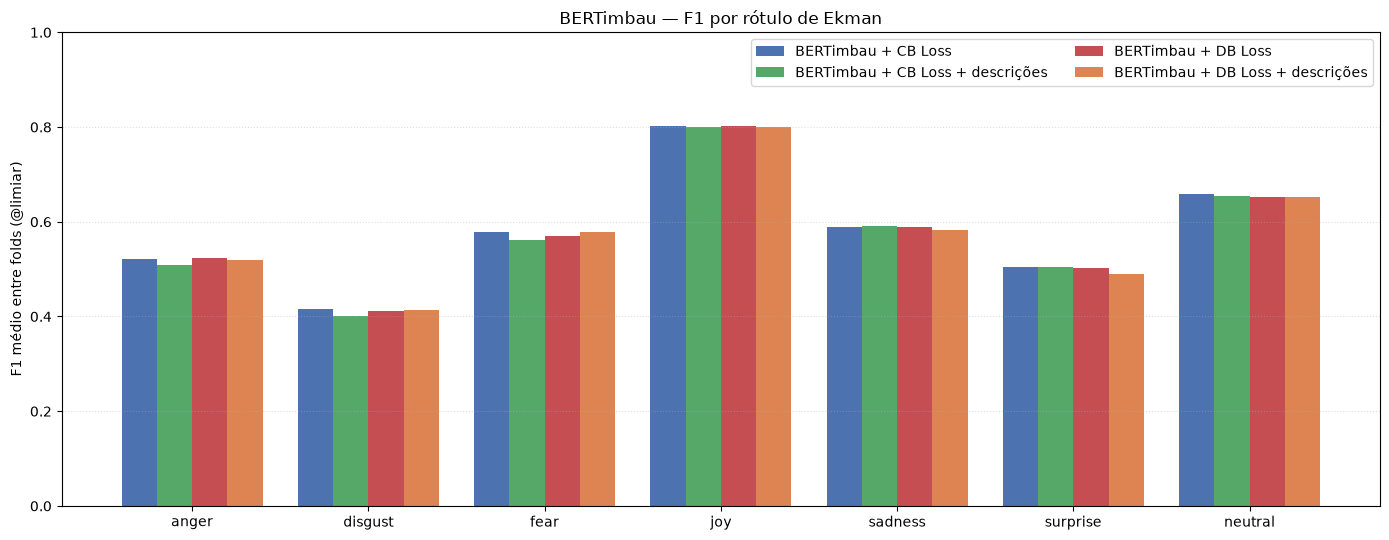

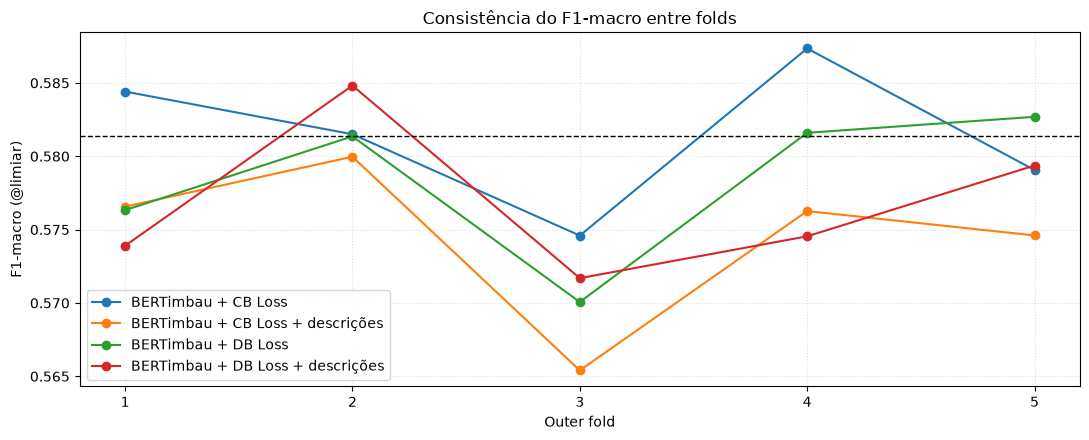

In [17]:
keys_to_plot = list(EXPERIMENTS)
f1_per_label = {
    key: pd.DataFrame([metric["f1_per_label"] for metric in metrics_tuned[key]]).mean().reindex(EKMAN7)
    for key in keys_to_plot
}

x = np.arange(len(EKMAN7))
width = 0.20
fig, ax = plt.subplots(figsize=(14, 5.5))
colors = ["#4C72B0", "#55A868", "#C44E52", "#DD8452"]
for index, key in enumerate(keys_to_plot):
    offset = (index - (len(keys_to_plot) - 1) / 2) * width
    ax.bar(x + offset, f1_per_label[key].values, width, label=DISPLAY_NAMES[key], color=colors[index])
ax.set_xticks(x)
ax.set_xticklabels(EKMAN7)
ax.set_ylim(0, 1)
ax.set_ylabel("F1 médio entre folds (@limiar)")
ax.set_title("BERTimbau — F1 por rótulo de Ekman")
ax.legend(ncol=2)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

fold_values = pd.DataFrame({DISPLAY_NAMES[key]: metric_frames[key]["f1_macro"] for key in keys_to_plot})
ax = fold_values.plot(marker="o", figsize=(11, 4.5))
ax.axhline(BASELINE_EXPECTED_MEAN, color="black", linestyle="--", linewidth=1, label="baseline informado")
ax.set_xticks(range(1, N_OUTER_FOLDS + 1))
ax.set_xlabel("Outer fold")
ax.set_ylabel("F1-macro (@limiar)")
ax.set_title("Consistência do F1-macro entre folds")
ax.grid(linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()


## Exportação

In [18]:
EXPORT_DIR = OUT_BASE / "final_bert_ekman"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

global_rows = []
for key, frame in metric_frames.items():
    for fold in frame.index:
        record = {"experiment": key, "model": DISPLAY_NAMES[key], "outer_fold": fold}
        record.update({metric: frame.loc[fold, metric] for metric in SUMMARY_KEYS})
        global_rows.append(record)

pd.DataFrame(global_rows).to_csv(EXPORT_DIR / "final_bert_ekman_metrics_by_fold.csv", index=False)
pd.DataFrame(f1_per_label).to_csv(EXPORT_DIR / "final_bert_ekman_f1_per_label.csv")
pd.concat({key: pd.DataFrame(thresholds_store[key], index=EKMAN7).T for key in thresholds_store}, names=["experiment", "outer_fold"]).to_csv(EXPORT_DIR / "final_bert_ekman_thresholds.csv")

summary = {
    "model": MODEL_NAME,
    "target": "Ekman direto — 6 grupos + neutral, multi-label",
    "baseline_expected": {"f1_macro_tuned_mean": BASELINE_EXPECTED_MEAN, "f1_macro_tuned_std": BASELINE_EXPECTED_STD},
    "baseline_recalculated": {"f1_macro_tuned_mean": float(baseline_mean), "f1_macro_tuned_std": float(baseline_std)},
    "experiments": {key: cfg["display"] for key, cfg in EXPERIMENTS.items()},
    "results_tuned": {
        key: {
            metric: {"mean": float(frame[metric].mean()), "std": float(frame[metric].std(ddof=0))}
            for metric in SUMMARY_KEYS
        }
        for key, frame in metric_frames.items()
    },
    "methodology": (
        "Outer CV com 5 folds; seleção de época por validação interna; OOF sem o respectivo fold de teste; "
        "limiar do fold k calibrado apenas nas OOF dos demais folds. O baseline CB reutiliza os arquivos de bert_ekman."
    ),
    "literature_note": (
        "O F1 0.64 do GoEmotions original usa inglês e agrupamento Ekman de seis categorias; não é diretamente comparável "
        "à configuração PT-BR com seis emoções mais neutral."
    ),
}

with open(EXPORT_DIR / "final_bert_ekman_summary.json", "w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2, ensure_ascii=False)

print("Arquivos exportados para", EXPORT_DIR.resolve())
print(json.dumps(summary, indent=2, ensure_ascii=False))


Arquivos exportados para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\final_bert_ekman
{
  "model": "neuralmind/bert-base-portuguese-cased",
  "target": "Ekman direto — 6 grupos + neutral, multi-label",
  "baseline_expected": {
    "f1_macro_tuned_mean": 0.5814,
    "f1_macro_tuned_std": 0.0044
  },
  "baseline_recalculated": {
    "f1_macro_tuned_mean": 0.5813839866646958,
    "f1_macro_tuned_std": 0.004387376819352744
  },
  "experiments": {
    "bert_cb": "BERTimbau + CB Loss",
    "bert_cb_desc": "BERTimbau + CB Loss + descrições",
    "bert_db": "BERTimbau + DB Loss",
    "bert_db_desc": "BERTimbau + DB Loss + descrições"
  },
  "results_tuned": {
    "bert_cb": {
      "accuracy": {
        "mean": 0.49711138162151824,
        "std": 0.006573502012634163
      },
      "hamming_loss": {
        "mean": 0.11497810556059662,
        "std": 0.0010920952530676725
      },
      "precision_macro": {
        "mean": 0.5514082257335865,
     